The bad result is:
{}


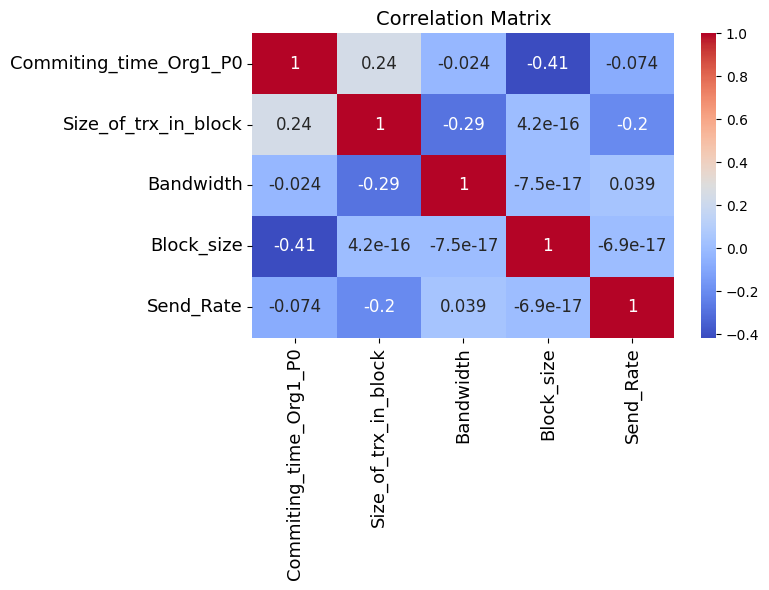

Correlation with 'Commiting_time_Org1_P0':
Commiting_time_Org1_P0    1.000000
throuout                  0.418056
Size_of_trx_in_block      0.237568
Bandwidth                -0.023637
Send_Rate                -0.074001
latancy                  -0.324069
Block_size               -0.414442
Name: Commiting_time_Org1_P0, dtype: float64

Feature Importances (impurity-based, fitted on train only):
            Feature  Importance
2        Block_size    0.862530
0  Transaction_Size    0.067666
3         Send_Rate    0.048398
1         Bandwidth    0.021406


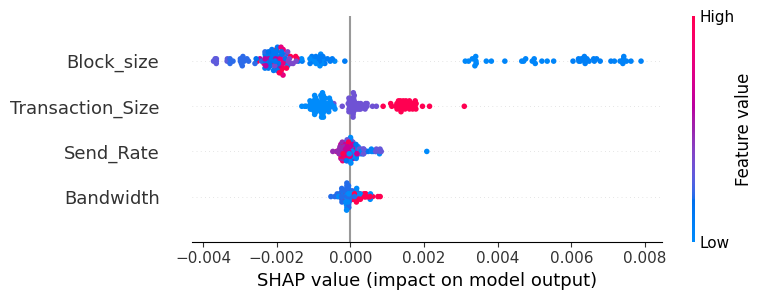

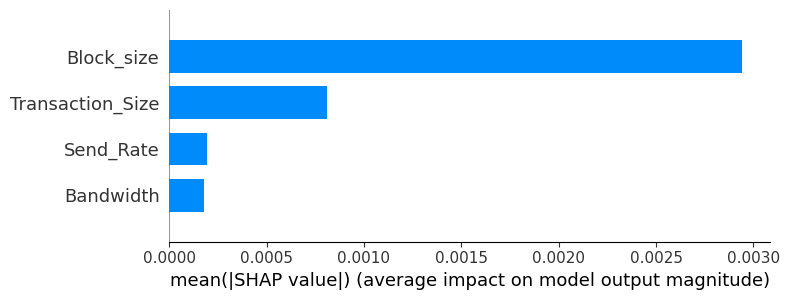


SHAP Feature Importances:
            Feature  mean_|SHAP|
2        Block_size     0.002939
0  Transaction_Size     0.000811
3         Send_Rate     0.000195
1         Bandwidth     0.000179

Top 2 Features (by SHAP):
['Block_size', 'Transaction_Size']


KeyError: "['Transaction_Size'] not in index"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                                8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                          1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                    5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Commiting_time_Org1_P0": [
0.01749344,
0.021569526,
0.022142483,
0.026179602,
0.024100623,
0.017171253,
0.014933794,
0.015301387,
0.016242518,
0.015594681,
0.01442018,
0.016346904,
0.015521765,
0.016147215,
0.016529971,
0.022469355,
0.026275061,
0.028773322,
0.030666072,
0.028396419,
0.021659875,
0.020003995,
0.019110697,
0.019151092,
0.018694759,
0.016092243,
0.017521711,
0.016130835,
0.015676871,
0.015709686,
0.017574153,
0.021122606,
0.022179243,
0.025783684,
0.023819928,
0.016589242,
0.015493515,
0.016794313,
0.016948402,
0.015036483,
0.014509665,
0.016263453,
0.015889414,
0.01591974,
0.016306376,
0.017585661,
0.021300903,
0.021924612,
0.024092736,
0.024057155,
0.017184492,
0.016557117,
0.016612641,
0.016245615,
0.016739352,
0.014963836,
0.016357022,
0.015678703,
0.016370872,
0.016218568,
0.01755675,
0.021626287,
0.023010256,
0.023611791,
0.023427744,
0.016951466,
0.016200131,
0.016936097,
0.016950999,
0.015253337,
0.014981802,
0.01722219,
0.016933896,
0.016735936,
0.015809598,
0.017416525,
0.02180219,
0.021811044,
0.025974688,
0.025099185,
0.01668303,
0.015562204,
0.016090675,
0.016798994,
0.015941583,
0.014738496,
0.016951077,
0.01610089,
0.016589017,
0.015992848,
0.017325161,
0.020740231,
0.021723587,
0.026746463,
0.023834537,
0.017121359,
0.016063866,
0.016316458,
0.017511898,
0.016104252,
0.01431789,
0.016130472,
0.015016848,
0.016705636,
0.016620482,
0.017380391,
0.020976443,
0.022307371,
0.024784431,
0.024075644,
0.017658118,
0.015562483,
0.016470585,
0.016882949,
0.015112953,
0.014898722,
0.016893276,
0.016234081,
0.015523991,
0.01596362,
0.017470967,
0.021347499,
0.022572511,
0.023836575,
0.023340654,
0.018702467,
0.016590442,
0.016573516,
0.016060298,
0.014794878,
0.014227568,
0.016167921,
0.016517656,
0.016682251,
0.017290692,
0.017379217,
0.021059445,
0.02148358,
0.025270752,
0.024348573,
0.018542436,
0.016076371,
0.015419324,
0.016858208,
0.016163129,
0.014662936,
0.016413266,
0.016060798,
0.015781028,
0.016286726,
0.017379217,
0.021059445,
0.02148358,
0.025270752,
0.024348573,
0.018542436,
0.016076371,
0.015419324,
0.016858208,
0.016163129,
0.014662936,
0.016413266,
0.016060798,
0.015781028,
0.016286726,
0.017741276,
0.021368133,
0.022384462,
0.02492454,
0.023936835,
0.016764453,
0.017331329,
0.016772216,
0.016068672,
0.015100756,
0.015722493,
0.016963065,
0.015877697,
0.016426762,
0.015934385,
0.017356557,
0.021740327,
0.022229145,
0.025320343,
0.02244556,
0.018928327,
0.016326523,
0.016205641,
0.016707761,
0.015377767,
0.014548668,
0.016455849,
0.016723787,
0.016866591,
0.016599785,
0.017734005,
0.022170855,
0.023256151,
0.025433603,
0.024553757,
0.018438608,
0.01654231,
0.015724219,
0.01680788,
0.016300256,
0.015461524,
0.017948996,
0.015528483,
0.015792956,
0.01671977,
0.017943923,
0.02157997,
0.023561571,
0.026785729,
0.02595258,
0.017673649,
0.016364126,
0.016975237,
0.016455008,
0.015824154,
0.014929579,
0.015989858,
0.015445897,
0.015923268,
0.01720642,
0.017673047,
0.022046647,
0.023056401,
0.024031615,
0.02512106,
0.016618955,
0.015688486,
0.016207598,
0.017012174,
0.015270672,
0.015327681,
0.017848091,
0.015496761,
0.017047764,
0.01676252,
0.017254216,
0.020704867,
0.022247026,
0.026509297,
0.02294057,
0.016823003,
0.016193456,
0.016333001,
0.016726638,
0.016465896,
0.015177428,
0.016748329,
0.015514209,
0.01572633,
0.016205104,
0.017669727,
0.021211484,
0.023113604,
0.026530625,
0.023758993,
0.017016312,
0.015793992,
0.016885885,
0.016013269,
0.014662726,
0.014792721,
0.016275353,
0.016594525,
0.017644173,
0.018791484,
0.020026061,
0.023074226,
0.023547497,
0.028466799,
0.025507564,
0.017053224,
0.016802905,
0.020006817,
0.016145983,
0.016338009,
0.015473123,
0.017218257,
0.016425573,
0.017854505,
0.017558043,
0.018571291,
0.023029914,
0.025524709,
0.027461438,
0.024819725,
0.019846039,
0.017789846,
0.017253915,
0.016950878,
0.016116659,
0.016068252,
0.016933812,
0.016628285,
0.017607496,
0.017631986,
0.017524141,
0.021710467,
0.023980923,
0.025619237,
0.024509387,
0.016140595,
0.018379184,
0.016194912,
0.015525228,
0.015513132,
0.015193536,
0.016841341,
0.015881927,
0.018439425,
0.016149385,
0.018172012,
0.021857609,
0.023269305,
0.02505562,
0.025945171,
0.017633783,
0.016380751,
0.017100314,
0.015937503,
0.015966764,
0.01490121,
0.016804472,
0.016318404,
0.015773882,
0.016886343,
0.017899768,
0.02187935,
0.024560987,
0.025804883,
0.024879913,
0.017103095,
0.018286028,
0.017377895,
0.015860683,
0.015704831,
0.015425112,
0.016897978,
0.01551178,
0.017483367,
0.016121909,
0.017717956,
0.021700177,
0.023386585,
0.025151855,
0.024612476,
0.017371112,
0.01506216,
0.016530589,
0.016054462,
0.016111996,
0.015018267,
0.016724938,
0.015863584,
0.016684614,
0.01657994,
0.018135267,
0.022078497,
0.02361343,
0.026640715,
0.026968632,
0.018456801,
0.018234522,
0.019252751,
0.024560448,
0.019526856,
0.016080544,
0.017889724,
0.017776513,
0.016994563,
0.017377742,
0.018099122,
0.022678502,
0.024121547,
0.026569657,
0.026098722,
0.018049159,
0.017672652,
0.017435701,
0.017297716,
0.016052384,
0.015433248,
0.01823122,
0.017232273,
0.017391197,
0.017451205,
0.018281871,
0.022450886,
0.025336318,
0.026449404,
0.026995109,
0.018181494,
0.017238782,
0.016187842,
0.0171932,
0.016616909,
0.015730043,
0.017018059,
0.016903619,
0.017103624,
0.016776332,
0.017815903,
0.021908154,
0.02359755,
0.025104721,
0.025596718,
0.018031344,
0.016274993,
0.017054142,
0.018630592,
0.016327052,
0.015133955,
0.017907128,
0.016724355,
0.01704106,
0.017792601,
0.018416623,
0.023225084,
0.023894495,
0.026501798,
0.025589129,
0.019318809,
0.01675772,
0.016347008,
0.018210681,
0.016781987,
0.015587925,
0.018093953,
0.017943566,
0.017275768,
0.017611165,
0.018202206,
0.022136457,
0.024684125,
0.027751649,
0.027536022,
0.021319907,
0.016645379,
0.01787883,
0.01573254,
0.017940481,
0.015663005,
0.017159216,
0.017515294,
0.016966971,
0.017050836,
0.018362219,
0.021826147,
0.024523186,
0.027084727,
0.025422554,
0.020052239,
0.016682415,
0.017141616,
0.017672677,
0.015066595,
0.016068004,
0.016974318,
0.016916382,
0.017387107,
0.016761986,
0.017647149,
0.021584275,
0.02355207,
0.027023597,
0.02422972,
0.017670248,
0.015990592,
0.01701504,
0.018840709,
0.015698543,
0.016255283,
0.017997714,
0.016590339,
0.017386075,
0.01730601,
0.01814634,
0.022984869,
0.023735275,
0.026118916,
0.024622077,
0.018241251,
0.019115184,
0.024146072,
0.018282254,
0.018157801,
0.017516288,
0.018852867,
0.016981033,
0.018188081,
0.017428264,
0.017872788,
0.02303531,
0.0236107,
0.027058858,
0.02599029,
0.017727987,
0.016624267,
0.016932793,
0.016432682,
0.017130683,
0.016821384,
0.018803257,
0.016438498,
0.017506298,
0.017388078,
0.018117332,
0.022667717,
0.024072381,
0.026112824,
0.02495002,
0.018570361,
0.017001171,
0.017813045,
0.016822712,
0.018812608,
0.016325975,
0.018063039,
0.017940818,
0.018037499,
0.017040978,
0.018076953,
0.022645697,
0.023524724,
0.025694877,
0.024590259,
0.019794169,
0.016460698,
0.017076029,
0.017678505,
0.016130022,
0.01686459,
0.018424058,
0.017147735,
0.017159372,
0.017864507,
0.017792428,
0.021872112,
0.023862068,
0.027874052,
0.026481526,
0.0183151,
0.017535005,
0.017526264,
0.016963527,
0.015481459,
0.016304658,
0.017701647,
0.017432833,
0.017753848,
0.017673027,
0.018346151,
0.022496849,
0.025129154,
0.027542297,
0.026258899,
0.019269297,
0.016365842,
0.017742419,
0.016786431,
0.01569216,
0.01591589,
0.018623658,
0.018366661,
0.018580623,
0.017569779,
0.018115039,
0.023194817,
0.023770143,
0.027299075,
0.026356934,
0.019376574,
0.017427452,
0.017799832,
0.016135263,
0.016783704,
0.01610701,
0.018497742,
0.017418604,
0.017515817,
0.017771439,
0.01987626,
0.024828504,
0.025083134,
0.038834313,
0.031024448,
0.021669239,
0.020976984,
0.021282631,
0.019731158,
0.019368362,
0.018582312,
0.020220151,
0.020744722,
0.020536445,
0.016883601,
0.018119062,
0.022723696,
0.024681527,
0.026630059,
0.024430214,
0.018489622,
0.016419188,
0.016691859,
0.015822435,
0.015561848,
0.016214497,
0.017827454,
0.016729577,
0.018906094,
0.017054937,
0.018473202,
0.022516054,
0.024148853,
0.025507718,
0.025185934,
0.019994179,
0.017185513,
0.017743824,
0.018307184,
0.016710777,
0.015886637,
0.017466492,
0.017405735,
0.017791579,
0.017515654,
0.020324779,
0.026488255,
0.029890385,
0.029329873,
0.026356028,
0.02029323,
0.02205882,
0.016815241,
0.017407077,
0.01812132,
0.016895524,
0.019435939,
0.018687924,
0.018848706,
0.018925976,
0.018994211,
0.022796252,
0.023879446,
0.028720806,
0.024887888,
0.017982306,
0.018625784,
0.017512448,
0.018473932,
0.016923893,
0.016706561,
0.019553751,
0.0183865,
0.018944583,
0.018325472,
0.019541353,
0.023900496,
0.025930163,
0.029836036,
0.027105673,
0.018878202,
0.018103908,
0.017571437,
0.018915851,
0.017100838,
0.017406587,
0.020003216,
0.018786505,
0.017477369,
0.01915849,
0.018823822,
0.02370911,
0.025704594,
0.029541418,
0.028542614,
0.020382188,
0.018915172,
0.019223549,
0.019075851,
0.017186343,
0.017865877,
0.018418483,
0.018718945,
0.019117504,
0.019295275,
0.019277719,
0.023586576,
0.024551008,
0.028667913,
0.029071657,
0.018930688,
0.018927713,
0.018892501,
0.017866368,
0.017253247,
0.017770089,
0.018314702,
0.01907017,
0.019418292,
0.018529344,
0.01948483,
0.023759937,
0.026911224,
0.02854483,
0.028055559,
0.020857746,
0.018324285,
0.018793508,
0.017696321,
0.018314555,
0.017370505,
0.01914177,
0.019062465,
0.018275456,
0.018164601,
0.020827185,
0.033333203,
0.029418893,
0.028614079,
0.026354916,
0.01894159,
0.017769637,
0.017543218,
0.017276744,
0.017649478,
0.017110969,
0.01869151,
0.017462369,
0.018555993,
0.017671909,
0.019267654,
0.023831496,
0.026210054,
0.029755822,
0.027114974,
0.01955886,
0.017107139,
0.019782454,
0.018747493,
0.017018158,
0.017531005,
0.019671883,
0.019308733,
0.019265865,
0.018937142,
0.01922966,
0.023804919,
0.027040879,
0.027948682,
0.029054092,
0.021011485,
0.019404979,
0.017894697,
0.019763456,
0.016563512,
0.017867873,
0.018735259,
0.022274304,
0.019772598,
0.01810275,
0.020041076,
0.024467841,
0.025695619,
0.029122563,
0.026647147,
0.019635754,
0.017900637,
0.018147426,
0.018327928,
0.017599327,
0.017073721,
0.019728253,
0.018173815,
0.01927863,
0.019169449,
0.019259784,
0.025142313,
0.025445876,
0.027784513,
0.026322403,
0.02084593,
0.017346457,
0.018020967,
0.017175592,
0.017619209,
0.017174026,
0.019958792,
0.018212646,
0.018731558,
0.018573945,
0.019392271,
0.023900359,
0.026050512,
0.029527081,
0.029922044,
0.018214939,
0.017255681,
0.019215999,
0.01816473,
0.018731139,
0.017294424,
0.019863491,
0.018187374,
0.01882314,
0.018952335,
                                   
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
                    33.7,
32.5,
31.2,
27.2,
33.8,
66.5,
23.8,
25.7,
24.5,
12.7,
5.6,
2.1,
0.7,
0.6,
0.7,
34.4,
34.6,
31.6,
28.1,
31.9,
60.9,
25.5,
23.9,
23,
11.2,
4,
2.1,
0.6,
0.6,
0.7,
34.1,
33.9,
31.6,
27.8,
33.3,
55.6,
26.5,
24.4,
19.6,
12.5,
4.2,
2.1,
0.7,
0.7,
0.6,
34.1,
34,
31.9,
28.1,
32.5,
55.8,
20.5,
23.9,
22.1,
14.4,
8,
2.1,
0.7,
0.7,
0.7,
34.1,
34.3,
30.8,
28.4,
32.9,
13.3,
23.5,
25.6,
21.1,
12.5,
2.9,
1.5,
0.7,
0.7,
0.6,
34,
33.7,
31.8,
28.3,
31.7,
63.5,
26.5,
25.1,
21.5,
12.1,
4.4,
1.4,
0.6,
0.7,
0.7,
                    33.3,
30.5,
30.3,
27.1,
30.9,
53.2,
23.9,
23.4,
24.9,
15.3,
4.1,
2.1,
0.6,
0.7,
0.6,
33.6,
34.4,
31.4,
27.3,
33.4,
64.1,
25.3,
24.3,
20.7,
15.2,
3.6,
2.1,
0.7,
0.7,
0.7,
34.3,
34.1,
30.9,
28.7,
33.5,
53.2,
25.5,
25,
21.4,
12.5,
5.7,
2.1,
0.7,
0.7,
0.7,
34.1,
34,
30.9,
29,
33.7,
64.4,
20.1,
23.7,
23.7,
18.4,
3.6,
2.1,
0.7,
0.6,
0.6,
34,
33.9,
30.7,
29.1,
33,
38.5,
26.6,
26.1,
21.9,
17.1,
4.2,
1.4,
0.7,
0.7,
0.7,
33.8,
33.9,
31.8,
27.1,
32,
42.7,
27.4,
25.9,
23.9,
16.4,
6,
2.2,
0.7,
0.7,
0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
               0.1,
0.13,
0.11,
0.11,
0.18,
0.1,
0.15,
0.16,
0.16,
0.49,
1.24,
4.24,
12.39,
13.61,
12.93,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.19,
0.57,
1.41,
4.21,
12.99,
13.74,
12.87,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.22,
0.5,
1.35,
4.48,
12.52,
12.6,
13.31,
0.1,
0.12,
0.1,
0.11,
0.19,
0.11,
0.18,
0.18,
0.19,
0.41,
0.94,
4.17,
12.45,
12.63,
12.85,
0.1,
0.12,
0.1,
0.11,
0.18,
0.31,
0.15,
0.17,
0.2,
0.5,
1.6,
7.35,
12.22,
12.63,
13.2,
0.1,
0.12,
0.1,
0.11,
0.19,
0.1,
0.14,
0.17,
0.19,
0.52,
1.39,
6.85,
12.3,
12.7,
12.88,
               
               0.11,
0.15,
0.11,
0.12,
0.19,
0.11,
0.15,
0.19,
0.16,
0.4,
1.42,
4.14,
12.87,
12.64,
13.11,
0.1,
0.12,
0.1,
0.12,
0.18,
0.1,
0.14,
0.17,
0.21,
0.41,
1.44,
4.28,
12.46,
12.57,
12.67,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.14,
0.17,
0.2,
0.5,
1.22,
4.13,
12.47,
12.57,
12.89,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.18,
0.18,
0.17,
0.32,
1.56,
4.18,
12.52,
13.72,
13.35,
0.1,
0.12,
0.1,
0.11,
0.18,
0.14,
0.13,
0.16,
0.19,
0.36,
1.33,
7.12,
12.42,
12.59,
12.55,
0.1,
0.12,
0.1,
0.12,
0.19,
0.13,
0.13,
0.16,
0.18,
0.38,
1.19,
4.05,
12.34,
12.6,
12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Commiting_time_Org1_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('Commiting_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Commiting_time_Org1_P0':")
print(correlation_matrix['Commiting_time_Org1_P0'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances

X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Commiting_time_Org1_P0']

# Fit Random Forest model
#######################################################################
# Use train/test split so importance is evaluated on unseen data
#mapping = {'Size_of_trx_in_block': 'Transaction_Size'}
#X = X.rename(columns=mapping)
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit Random Forest model on training data only
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_fi, y_train_fi)

# Feature importances (impurity-based, from training set)
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (impurity-based, fitted on train only):")
print(importance_df)

# --- SHAP feature importance (computed on test set) ---
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_fi)

# SHAP summary plot (bee-swarm)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, show=False)
plt.tight_layout()
plt.savefig('Shap_Commiting_p0Org1.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

# SHAP bar plot (mean |SHAP|)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, plot_type='bar', show=False)
plt.tight_layout()

plt.show()

# Choose the two most important features based on mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'Feature': feature_names, 'mean_|SHAP|': mean_abs_shap}).sort_values(by='mean_|SHAP|', ascending=False)
print("\nSHAP Feature Importances:")
print(shap_importance_df)

top_features = shap_importance_df.head(2)['Feature'].tolist()
print("\nTop 2 Features (by SHAP):")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing impurity-based feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (trained on train set only)')

plt.show()

##########################################################################



np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Commiting_time_Org1_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Commiting_time_Org1_P0',
    2: 'Size_of_transaction',
    3: 'Bandwidth',
    4: 'Block_size',
    5: 'Send_Rate'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('calidation_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.002880222289494742, 'RMSE': 0.0035275797946883324, 'MSE': 1.2443819207893378e-05, 'R2': -0.000513587699519702, 'MAPE(%)': 14.348419197621068}
Baseline (Block_size only): {'MAE': 0.002734789093277374, 'RMSE': 0.0032468343452311454, 'MSE': 1.0541933265372561e-05, 'R2': 0.15240270720612792, 'MAPE(%)': 13.929991687998141}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0027619110
  RMSE:    0.0032304026
  MSE:     1.0435500729e-05
  R2:      0.160960
  MAPE(%): 13.9636

Decision Tree:
  MAE:     0.0012393651
  RMSE:    0.0018153297
  MSE:     3.2954220286e-06
  R2:      0.735040
  MAPE(%): 6.2986

Random Forest:
  MAE:     0.0008906647
  RMSE:    0.0012133175
  MSE:     1.4721393761e-06
  R2:      0.881636
  MAPE(%): 4.5707

XGBoost:
  MAE:     0.0007393892
  RMSE:    0.0010842891
  MSE:     1.1756829338e-06
  R2:      0.905472
  MAPE(%): 3.7863

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (0.00164204 * 

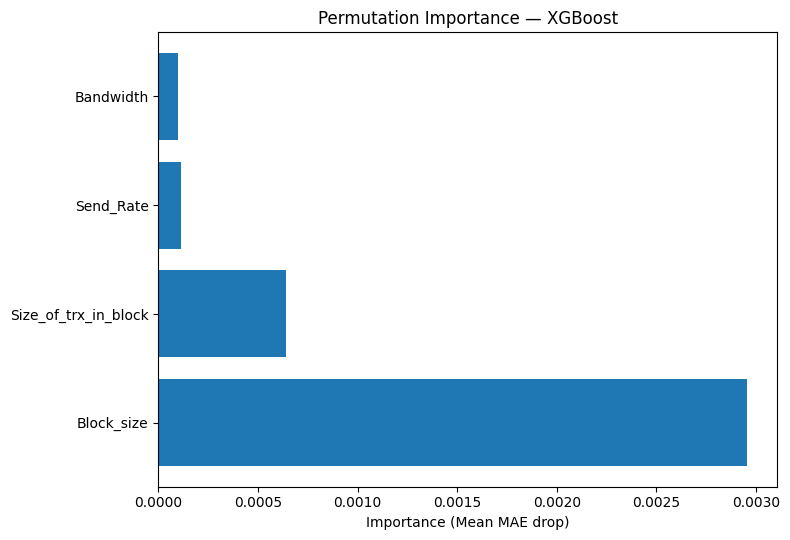

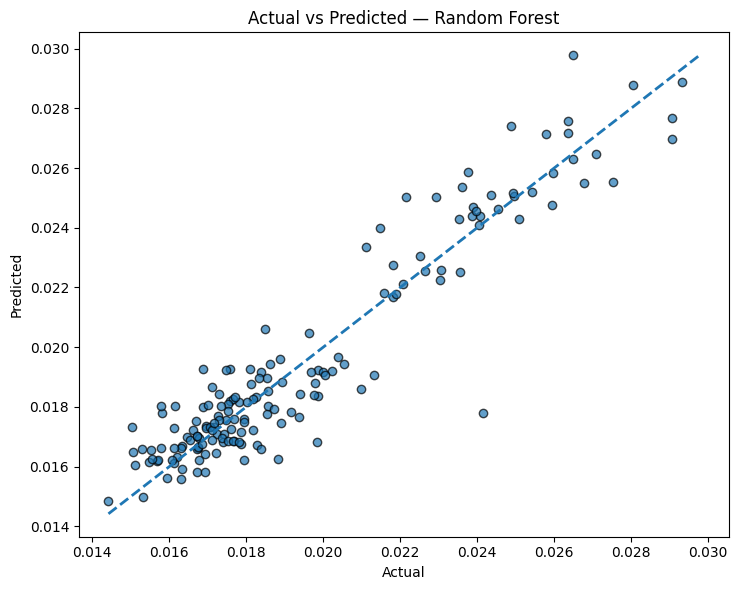

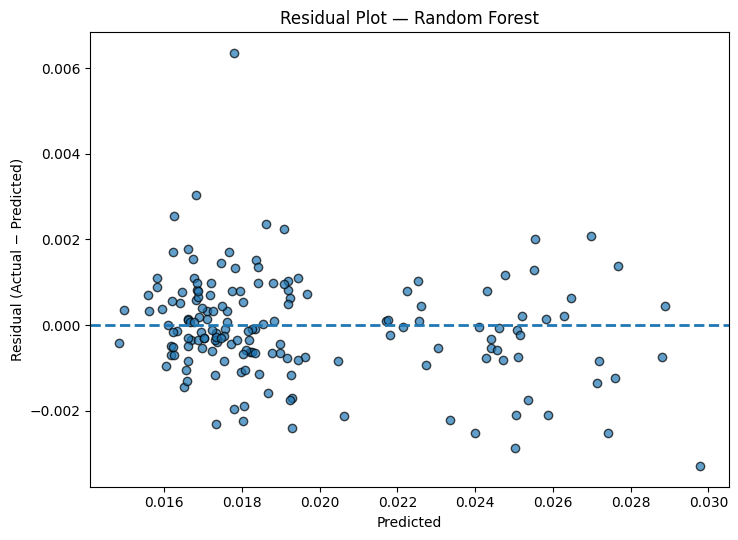

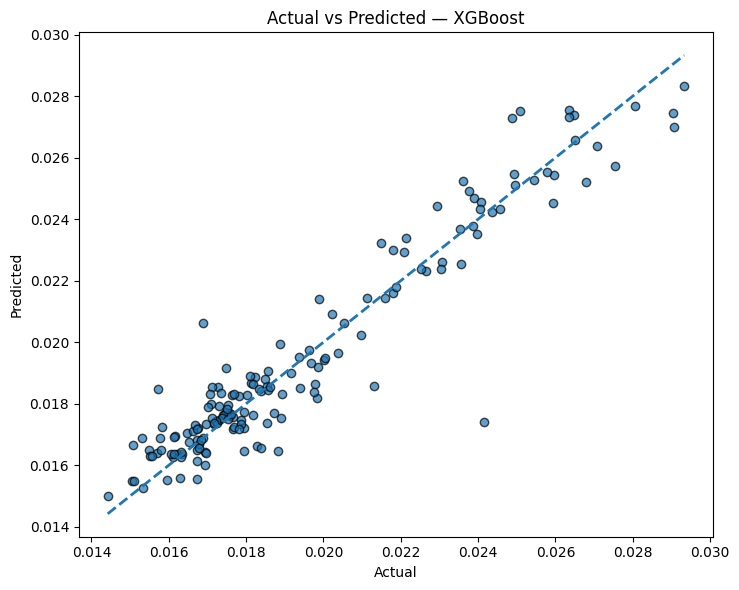

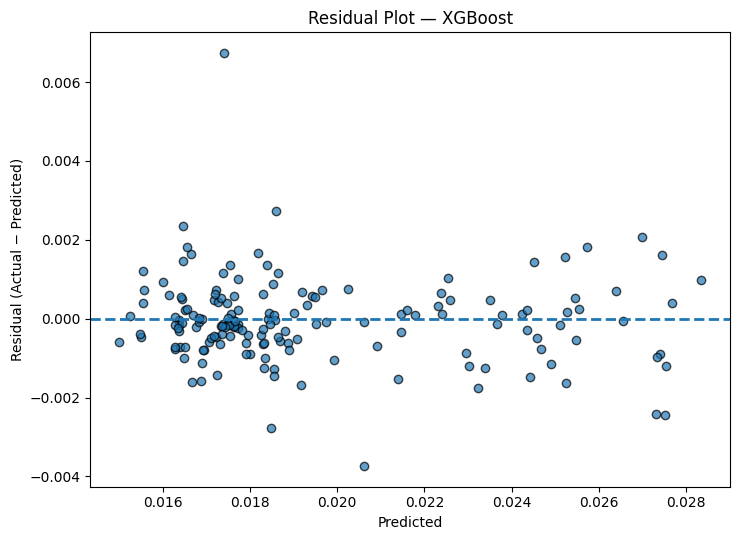

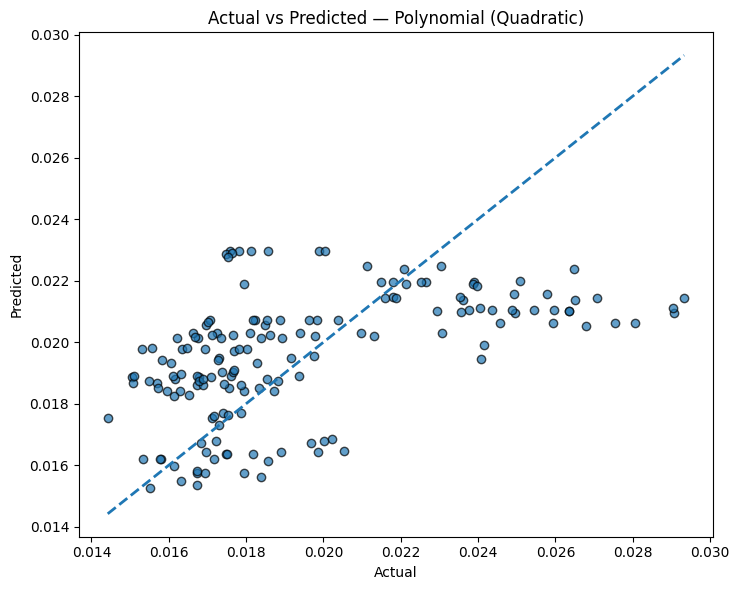

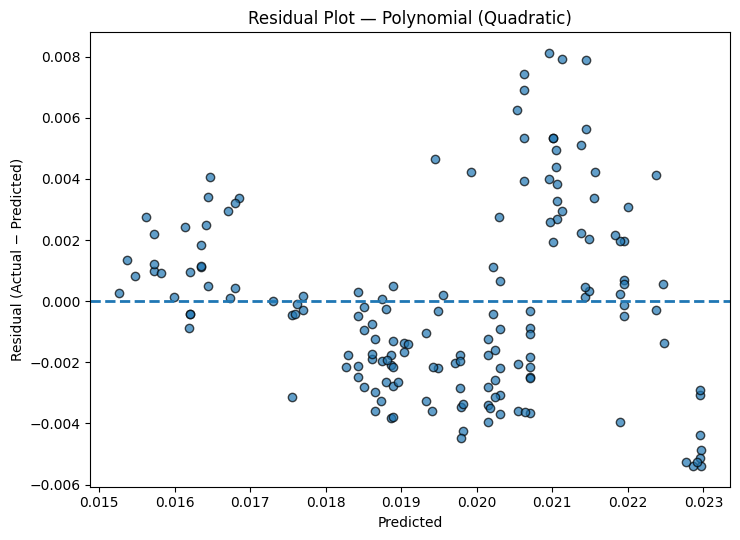

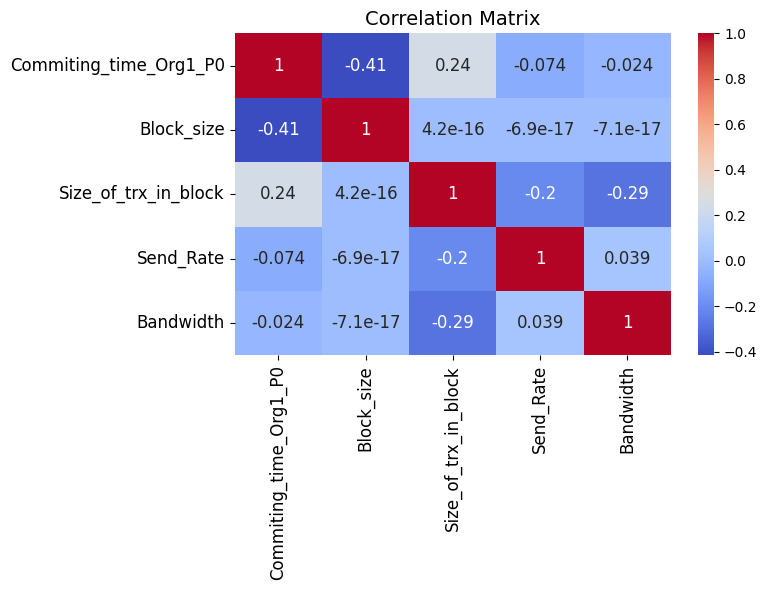

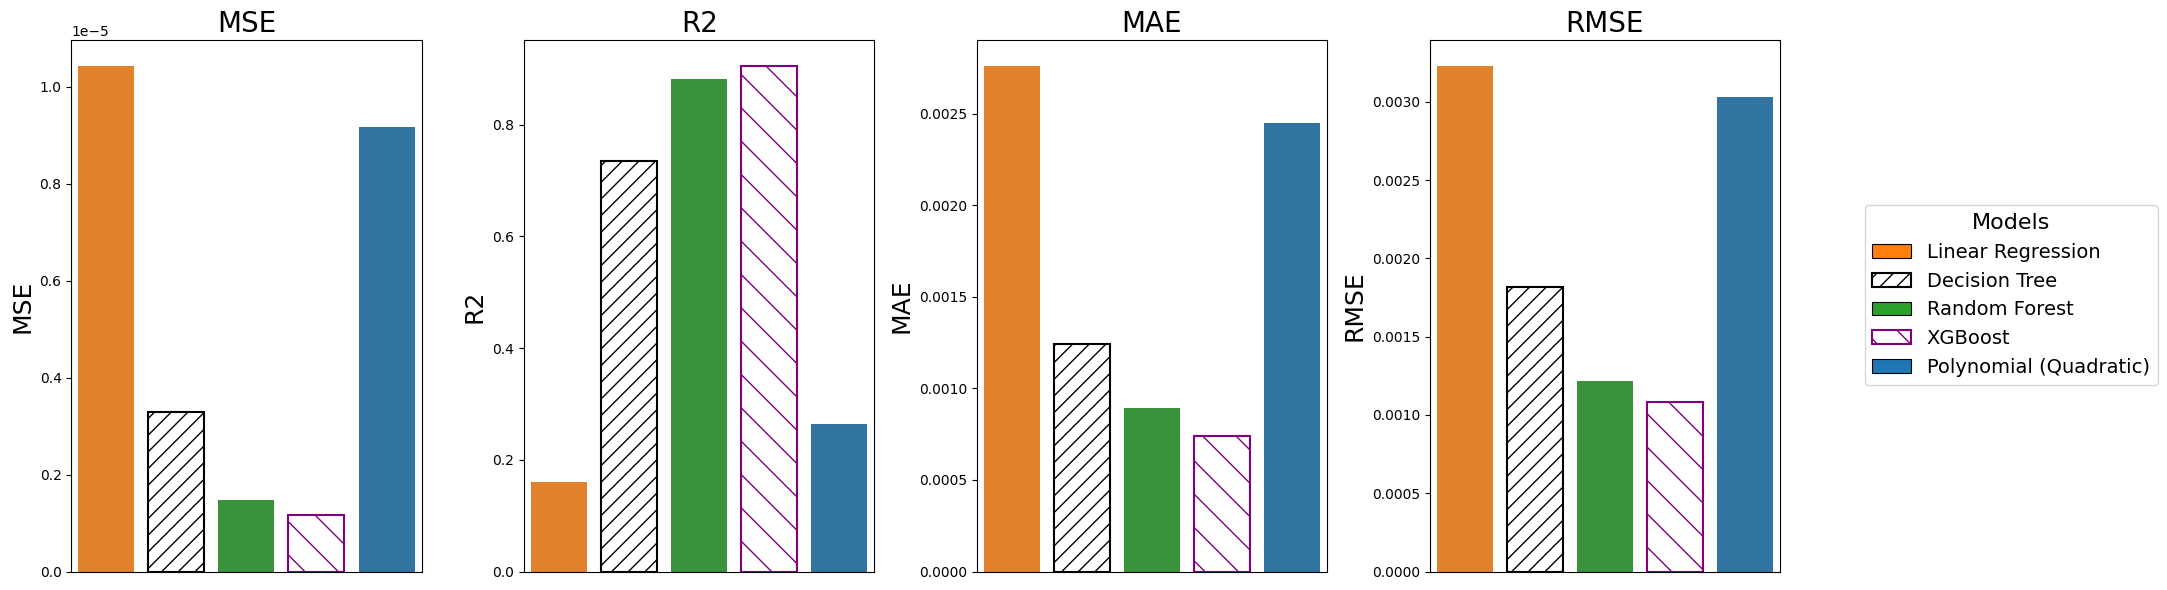

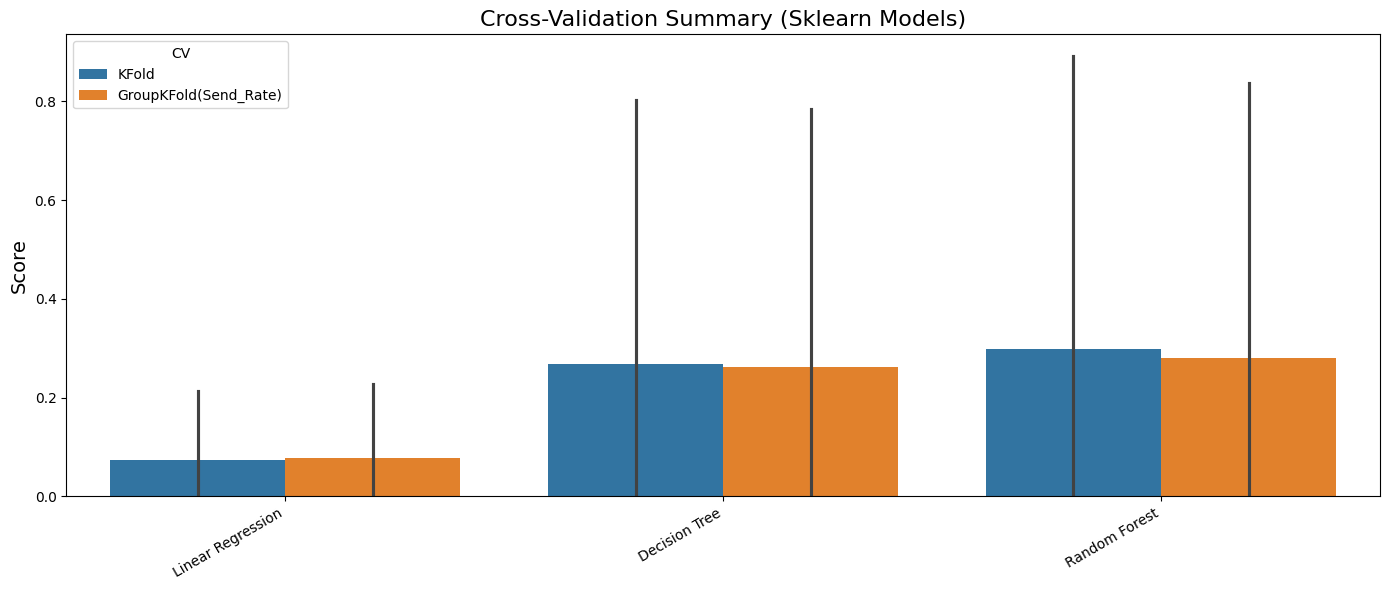


Saved models and quadratic artifacts successfully.


In [5]:
 #all model for peer0-Org1 commiting time v2  



import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Commiting_time_Org1_P0'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance 
# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])
perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea)
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "MSE", "R2", "MAE", "RMSE"]],
    metric_names=["MSE", "R2","MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)



# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "CP0Org1_linear_model.pkl")
joblib.dump(models["Decision Tree"], "CP0Org1_tree_model.pkl")
joblib.dump(models["Random Forest"], "CP0Org1_forest_model.pkl")
joblib.dump(models["XGBoost"], "CP0Org1_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "CP0Org1_quadratic_params.pkl")
joblib.dump(scaler_quad, "CP0Org1_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")



In [1]:
!pip install nbdime


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.11/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
pip install nbdime

Note: you may need to restart the kernel to use updated packages.


In [4]:
!nbdiff-web correct.ipynb fix_load_commiting_p0Org1.ipynb

/bin/bash: line 1: nbdiff-web: command not found


In [5]:
!python -m nbdime nbdiff-web correct.ipynb fix_load_commiting_p0Org1.ipynb

/usr/bin/python: No module named nbdime


In [6]:
import sys
import os

# Add the standard local bin directory to the path
os.environ['PATH'] += os.pathsep + os.path.expanduser('~/.local/bin')

!nbdiff-web correct.ipynb fix_load_commiting_p0Org1.ipynb

/bin/bash: line 1: nbdiff-web: command not found


In [7]:
!nbdime extensions --enable --user

/bin/bash: line 1: nbdime: command not found
